# 🧠 TP 1 : du classifieur linéaire au MLP avec PyTorch

**Durée indicative : 2 h — Prérequis : tenseurs, dérivées et découpage train/test.**

## Objectifs observables

1. vérifier expérimentalement qu'un modèle linéaire ne résout pas XOR ;
2. entraîner un MLP avec des logits et `BCEWithLogitsLoss` ;
3. mesurer la généralisation sur des points non utilisés à l'entraînement ;
4. comparer des activations avec une initialisation et un protocole communs.


## 1. Imports et Le "Guide de Survie PyTorch pour Débutant"

> 💡 **Le Rituel d'Entraînement PyTorch (À mémoriser absolument !)** :
> À chaque itération de la boucle d'apprentissage, 5 étapes se succèdent toujours dans le même ordre :
> 1. `predictions = model(X)` : **Passe avant (*Forward pass*)** -> le modèle donne ses prédictions.
> 2. `loss = criterion(predictions, y)` : **Calcul de l'erreur** -> le thermomètre mesure l'écart avec la réalité.
> 3. `optimizer.zero_grad()` : **Remise à zéro** -> on vide les anciens gradients accumulés en mémoire.
> 4. `loss.backward()` : **Rétropropagation** -> calcul automatique de toutes les dérivées partielles.
> 5. `optimizer.step()` : **Mise à jour** -> l'optimiseur ajuste tous les poids dans la bonne direction !

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

print(f"Version de PyTorch : {torch.__version__}")


Version de PyTorch : 2.14.0


## 2. Le modèle linéaire et le problème XOR

Considérons les quatre points de la fonction logique XOR :

- $(0, 0) \to 0$
- $(0, 1) \to 1$
- $(1, 0) \to 1$
- $(1, 1) \to 0$

Ils ne sont pas séparables par une seule droite.


In [2]:
X_xor = torch.tensor(
    [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]],
    dtype=torch.float32,
)
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

linear_model = nn.Linear(2, 1)  # Produit des logits, sans sigmoïde intégrée.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(linear_model.parameters(), lr=0.1)

losses_linear = []
for _ in range(1000):
    optimizer.zero_grad()
    logits = linear_model(X_xor)
    loss = criterion(logits, y_xor)
    loss.backward()
    optimizer.step()
    losses_linear.append(loss.item())

with torch.no_grad():
    probabilities = torch.sigmoid(linear_model(X_xor))
    predictions = (probabilities >= 0.5).int()

print(f"Perte finale du modèle linéaire : {losses_linear[-1]:.4f}")
print("Probabilités :", probabilities.flatten().numpy().round(3).tolist())
print("Prédictions  :", predictions.flatten().tolist())
print("Cibles       :", y_xor.int().flatten().tolist())
assert not torch.equal(predictions, y_xor.int())


Perte finale du modèle linéaire : 0.6932
Probabilités : [0.49799999594688416, 0.5, 0.5, 0.5019999742507935]
Prédictions  : [0, 0, 0, 1]
Cibles       : [0, 1, 1, 0]


Le modèle linéaire ne peut pas représenter les quatre sorties de XOR simultanément. La prédiction exacte peut varier avec l'initialisation ; c'est la contrainte géométrique, et non une liste de sorties particulière, qui constitue le résultat.

---

## 3. La solution : un perceptron multicouche

Une couche cachée et une activation non linéaire permettent de construire plusieurs frontières linéaires combinées.


In [3]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.network(x)  # Logits bruts.


torch.manual_seed(42)
mlp_xor = MultiLayerPerceptron(input_dim=2, hidden_dim=8)
optimizer_mlp = optim.Adam(mlp_xor.parameters(), lr=0.03)
losses_mlp = []

for _ in range(1500):
    optimizer_mlp.zero_grad()
    logits = mlp_xor(X_xor)
    loss = criterion(logits, y_xor)
    loss.backward()
    optimizer_mlp.step()
    losses_mlp.append(loss.item())

with torch.no_grad():
    xor_predictions = (torch.sigmoid(mlp_xor(X_xor)) >= 0.5).int()

print(f"Perte finale du MLP : {losses_mlp[-1]:.6f}")
print("Prédictions :", xor_predictions.flatten().tolist())
assert torch.equal(xor_predictions, y_xor.int())


Perte finale du MLP : 0.000071
Prédictions : [0, 1, 1, 0]


## 4. Application sur un Problème Complexe : Les Deux Lunes (`make_moons`)

Générons 800 points formant deux demi-cercles entrelacés et entraînons un MLP complet.


In [4]:
X_np, y_np = make_moons(n_samples=800, noise=0.20, random_state=42)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np,
    y_np,
    test_size=0.25,
    random_state=42,
    stratify=y_np,
)

X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

class MoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)


torch.manual_seed(42)
model = MoonClassifier()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()
history = []

for _ in range(500):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    history.append(loss.item())

model.eval()
with torch.no_grad():
    test_predictions = (torch.sigmoid(model(X_test_t)) >= 0.5).float()
    test_accuracy = (test_predictions == y_test_t).float().mean().item()

print(f"Perte finale sur train : {history[-1]:.4f}")
print(f"Exactitude sur test     : {test_accuracy:.2%}")


Perte finale sur train : 0.0671
Exactitude sur test     : 96.00%


## 5. Visualisation de la Frontière de Décision Non-Linéaire


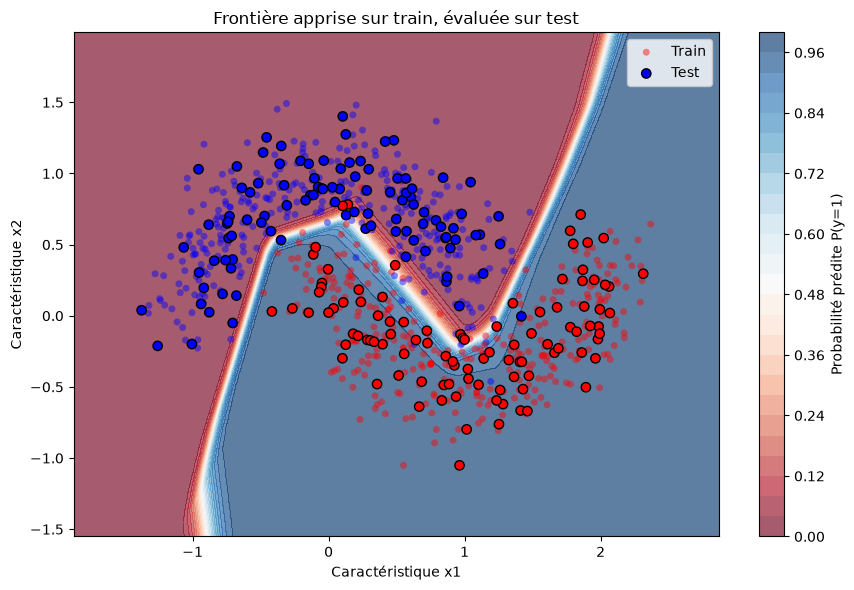

In [5]:
model.eval()
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)

grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    probabilities_grid = torch.sigmoid(model(grid_tensor)).reshape(xx.shape).numpy()

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, probabilities_grid, levels=25, cmap='RdBu', alpha=0.65)
plt.colorbar(label="Probabilité prédite P(y=1)")
plt.scatter(
    X_train_np[:, 0], X_train_np[:, 1], c=y_train_np,
    cmap='bwr', edgecolors='none', s=25, alpha=0.45, label='Train'
)
plt.scatter(
    X_test_np[:, 0], X_test_np[:, 1], c=y_test_np,
    cmap='bwr', edgecolors='black', s=45, marker='o', label='Test'
)
plt.title("Frontière apprise sur train, évaluée sur test")
plt.xlabel("Caractéristique x1")
plt.ylabel("Caractéristique x2")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Exercice guidé : impact de la fonction d'activation

Comparez `ReLU`, `Tanh` et `Sigmoid` avec la même architecture, la même graine, les mêmes données et le même nombre d'époques. Tracez les pertes de train puis comparez aussi l'exactitude de test.

**Critère de réussite** : la conclusion doit citer les valeurs observées et reconnaître qu'elle dépend du jeu de données et des hyperparamètres.


In [6]:
# À vous de jouer.
# TODO : écrire une boucle qui entraîne les trois activations avec le même protocole.


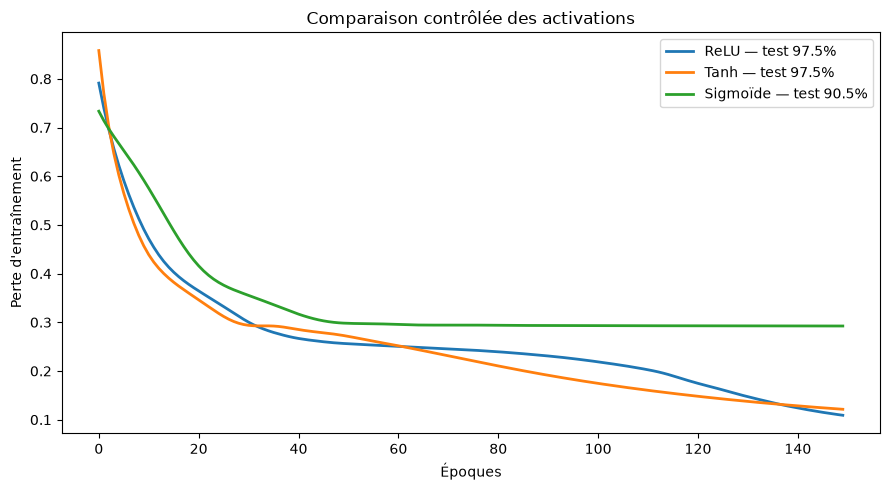

{'ReLU': {'loss': 0.10905652493238449, 'accuracy': 0.9750000238418579}, 'Tanh': {'loss': 0.12135039269924164, 'accuracy': 0.9750000238418579}, 'Sigmoïde': {'loss': 0.292375385761261, 'accuracy': 0.9049999713897705}}


In [7]:
activations = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "Sigmoïde": nn.Sigmoid(),
}
activation_results = {}
plt.figure(figsize=(9, 5))

for name, activation in activations.items():
    torch.manual_seed(123)  # Même initialisation des couches linéaires.
    test_model = nn.Sequential(
        nn.Linear(2, 16),
        activation,
        nn.Linear(16, 1),
    )
    optimizer_test = optim.Adam(test_model.parameters(), lr=0.03)
    losses = []

    for _ in range(150):
        optimizer_test.zero_grad()
        logits = test_model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer_test.step()
        losses.append(loss.item())

    test_model.eval()
    with torch.no_grad():
        predictions = (torch.sigmoid(test_model(X_test_t)) >= 0.5).float()
        accuracy = (predictions == y_test_t).float().mean().item()
    activation_results[name] = {"loss": losses[-1], "accuracy": accuracy}
    plt.plot(losses, label=f"{name} — test {accuracy:.1%}", lw=2)

plt.xlabel("Époques")
plt.ylabel("Perte d'entraînement")
plt.title("Comparaison contrôlée des activations")
plt.legend()
plt.tight_layout()
plt.show()
print(activation_results)


In [8]:
assert len(X_train_t) + len(X_test_t) == len(X_np)
assert test_accuracy >= 0.80, "Le MLP n'a pas dépassé la baseline pédagogique."
assert all(np.isfinite(result['loss']) for result in activation_results.values())
print("Contrôles finaux réussis.")


Contrôles finaux réussis.


## Conclusion et auto-évaluation

- Une couche linéaire ne peut pas séparer XOR.
- `BCEWithLogitsLoss` combine sigmoïde et entropie croisée de façon numériquement stable ; la sigmoïde est appliquée explicitement pour lire les probabilités.
- Une frontière convaincante sur le train ne suffit pas : l'exactitude est calculée sur un test séparé.
- Une comparaison d'activations n'est loyale que si le reste du protocole est contrôlé.
